# UNet based Fire Risk Predictor

This notebook builds a "fire-risk" predictor with the UNet backbone. The idea is that it performs segmentation on the source image to label which CA cells are in danger of being lit on fire in the near future. It does this using a base image and a ground truth image. The base image represents the initial condition, and the ground truth represents the effects the fire will have had after a set number of simulation steps. We want all newly destroyed cells (burnt to ash) to be classified as "Destroyed" and all burning cells to be classified as burning.

The output of this classifier will be fed into the next stage of the fire-fighting system.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import random

import os
import random
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split

import segmentation_models_pytorch as smp

from UNet import UNet

from tqdm import tqdm

## Dataset Wrapper

In [2]:
# image folder locations
notebook_dir = Path.cwd()
images_dir = (notebook_dir / ".." / "DatasetGenerator" / "data" / "base").resolve()
labels_dir = (notebook_dir / ".." / "DatasetGenerator" / "data" / "gt").resolve()

images_dir_str = str(images_dir)
labels_dir_str = str(labels_dir)

In [3]:
class FirePredictionDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        """
        Args:
            images_dir (str): Path to the directory containing raw images.
            labels_dir (str): Path to the directory containing segmentation labels.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform

        self.image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.png'))]

    def __len__(self):
        """
        Returns the number of image_files.
        """
        return len(self.image_files)

    def _load_label(self, base_name, img_shape):
        """
        Helper to find and load the corresponding label
        
        Args:
            base_name: The name of the source image (without extension)
            img_shape: The shape of the source image.

        Returns:
            A numpy array representing the mask label
        """

        base_path = os.path.join(self.images_dir, f"{base_name}.png") 

        label_name = base_name.replace("base", "gt")
        label_name = f"{label_name}.png"
        label_path = os.path.join(self.labels_dir, label_name)
        if not os.path.exists(label_path):
            raise Exception(f"Unable to find label associated with {base_name}")
        
        # load the base image and ground truth as numpy arrays
        base_arr = np.array(Image.open(base_path).convert("RGB"))
        gt_arr = np.array(Image.open(label_path).convert("RGB"))
        
        # 1. Detect active fire in base image (on fire at the start)
        base_fire = (
            ((base_arr[:, :, 0] == 255) & (base_arr[:, :, 1] == 0) & (base_arr[:, :, 2] == 0)) |
            ((base_arr[:, :, 0] == 255) & (base_arr[:, :, 1] == 69) & (base_arr[:, :, 2] == 0))
        )
        
        # 2. Detect active fire in ground truth image (on fire at the end)
        gt_fire = (
            ((gt_arr[:, :, 0] == 255) & (gt_arr[:, :, 1] == 0) & (gt_arr[:, :, 2] == 0)) |
            ((gt_arr[:, :, 0] == 255) & (gt_arr[:, :, 1] == 69) & (gt_arr[:, :, 2] == 0))
        )
        
        # 3. Detect cells that burned to ash during the segment
        base_ash = (base_arr[:, :, 0] == 128) & (base_arr[:, :, 1] == 128) & (base_arr[:, :, 2] == 128)
        gt_ash = (gt_arr[:, :, 0] == 128) & (gt_arr[:, :, 1] == 128) & (gt_arr[:, :, 2] == 128)
        destroyed = gt_ash & (~base_ash)
        
        # 4. Create binary mask: 0 (Safe) vs 1 (Risky)
        height, width = gt_arr.shape[0], gt_arr.shape[1]
        mask = np.zeros((height, width), dtype=np.uint8)
        
        # Risky is anything currently on fire or burned during the segment
        risky = base_fire | gt_fire | destroyed
        mask[risky] = 1

        return mask

    def __getitem__(self, idx):
        """
        Gets the next image/label pair from the dataset.

        Args:
            idx: index of the image/label pair to grab.
        """
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        base_name = os.path.splitext(img_name)[0]
        
        img = Image.open(img_path).convert('RGB')
        img_array = np.array(img)
        
        label_array = self._load_label(base_name, img_array.shape)
        label_tensor = torch.from_numpy(label_array).long()
        
        if self.transform:
            img_tensor = self.transform(img)

            h, w = img_tensor.shape[1], img_tensor.shape[2]
                    
            label_tensor = torch.nn.functional.interpolate(
                    label_tensor.unsqueeze(0).unsqueeze(0).float(), 
                    size=(h, w), 
                    mode='nearest'
                ).squeeze(0).squeeze(0).long()

        else:
            img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).float() / 255.0

        return img_tensor, label_tensor


## Create the Dataset Object 

In [4]:
standard_transform_pipeline = transforms.Compose([
    transforms.Resize((512, 512)),       
    transforms.ToTensor(),                             
    transforms.Normalize((0.5,), (0.5,))               
])

In [5]:
standard_dataset = FirePredictionDataset(
    images_dir=images_dir, 
    labels_dir=labels_dir,
    transform=standard_transform_pipeline
)

In [6]:
training_ratio = 0.7
validation_ratio = 0.15

total_size = len(standard_dataset)
train_size = int(training_ratio * total_size)
val_size = int(validation_ratio * total_size)
test_size = total_size - train_size - val_size

In [7]:
print(f"Total Size: {total_size}")
print(f"Train Size: {train_size}")
print(f"Validation Size: {val_size}")
print(f"Test Size: {test_size}")

Total Size: 10000
Train Size: 7000
Validation Size: 1500
Test Size: 1500


In [8]:
std_train_dataset, std_val_dataset, std_test_dataset = random_split(
    standard_dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) 
)

## Train UNet Model

In [9]:
torch.cuda.empty_cache()

LEARNING_RATE = 0.001
BATCH_SIZE = 8
num_workers = 0

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet(in_channels=3, num_classes=1).to(device) 
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',      
    factor=0.5,       
    patience=3,       
)

# there is a class balance issue between safe and unsafe pixels. We use a hybrid loss function to 
# try and get around this.
pos_weight = torch.tensor([0.5]).to(device)
bce_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
dice_criterion = smp.losses.DiceLoss(mode="binary", from_logits=True)


In [10]:
std_train_dataloader = DataLoader(
                                dataset=std_train_dataset,
                                num_workers=num_workers, 
                                pin_memory=False,
                                batch_size=BATCH_SIZE,
                                shuffle=True
                            )

std_val_dataloader = DataLoader(
                                dataset=std_val_dataset,
                                num_workers=num_workers, 
                                pin_memory=False,
                                batch_size=BATCH_SIZE,
                                shuffle=False
                            )

std_test_dataloader = DataLoader(
                                dataset=std_test_dataset,
                                num_workers=num_workers, 
                                pin_memory=False,
                                batch_size=BATCH_SIZE,
                                shuffle=False
                            )

In [11]:
def train_model(model, epochs, train_dataloader, val_dataloader, patience=5, min_delta=0.0, scheduler=None, model_file=None):
    """
    Trains a semantic segmentation model using pytorch.

    Args:
        model: The model we wish to train.
        epochs: The number of epoches to train the model for.
        train_dataloader: The training dataloader
        val_dataloader: The validation dataloader.
        patience: Number of epochs to wait for validation loss improvement.
        min_delta: Minimum change to qualify as an improvement.
        model_file: The file name to save the model to.

    Returns:
        train_losses: Array of losses from training.
        val_losses: Array of losses from the validation step
    """
    train_losses = []
    val_losses = [] 
    
    # Early stopping trackers
    best_val_loss = float('inf')
    best_model_weights = None
    patience_counter = 0
    
    for epoch in tqdm(range(epochs)):
        model.train()
        train_running_loss = 0
        
        for idx, img_mask in enumerate(tqdm(train_dataloader, position=0, leave=True)):
            img = img_mask[0].float().to(device)
            mask = img_mask[1].float().unsqueeze(1).to(device)
            
            y_pred = model(img)
            optimizer.zero_grad()
            loss = closs = 0.5 * bce_criterion(y_pred, mask) + 0.5 * dice_criterion(y_pred, mask)
            
            train_running_loss += loss.item()
       
            loss.backward()
            optimizer.step()

        train_loss = train_running_loss / (idx + 1)
        train_losses.append(train_loss)
       
        model.eval()
        val_running_loss = 0
        
        with torch.no_grad():
            for idx, img_mask in enumerate(tqdm(val_dataloader, position=0, leave=True)):
                img = img_mask[0].float().to(device)
                mask = img_mask[1].float().unsqueeze(1).to(device)

                y_pred = model(img)
                loss = loss = 0.5 * bce_criterion(y_pred, mask) + 0.5 * dice_criterion(y_pred, mask)   
                val_running_loss += loss.item()
        
            val_loss = val_running_loss / (idx + 1)
        
        val_losses.append(val_loss)
        
        print("-" * 30)
        print(f"Training Loss EPOCH {epoch + 1}: {train_loss:.4f}")
        print(f"Validation Loss EPOCH {epoch + 1}: {val_loss:.4f}")
        print("-" * 30)
        
        if scheduler is not None:
            # ReduceLROnPlateau requires the validation metric (loss) to monitor
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Early Stopping Logic
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            
            if model_file is not None:
                torch.save(model.state_dict(), model_file)
        else:
            patience_counter += 1
            print(f"EarlyStopping counter: {patience_counter} out of {patience}")
            if patience_counter >= patience:
                print("Early stopping triggered! Restoring best model weights...")
                break

    # Restore best weights if early stopping or normal termination occurred
    if best_model_weights is not None:
        best_device_weights = {k: v.to(device) for k, v in best_model_weights.items()}
        model.load_state_dict(best_device_weights)

    if model_file is not None:
        torch.save(model.state_dict(), model_file)
    
    return train_losses, val_losses


In [12]:
def plot_losses(train_losses, val_losses, filename="images/losses.png"):
    """
    Plots the training and validation losses.

    Args:
        train_losses: An array of training losses (obtained from train_model function)
        val_losses: An array of validation losses (obtained from tain_model function)
    """

    plt.figure(figsize=(16, 8))
    plt.plot(train_losses, label='Training Losses', color='green', marker='^')
    plt.plot(val_losses, label='Validation Losses', color='orange', marker='d')
    plt.title("Training and Validation Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.savefig(filename);

 10%|█         | 1/10 [07:10<1:04:38, 430.90s/it]

------------------------------
Training Loss EPOCH 1: 0.2554
Validation Loss EPOCH 1: 0.1944
------------------------------


 20%|██        | 2/10 [12:55<50:39, 379.89s/it]  

------------------------------
Training Loss EPOCH 2: 0.1872
Validation Loss EPOCH 2: 0.1838
------------------------------


 30%|███       | 3/10 [18:30<41:58, 359.81s/it]

...

------------------------------
Training Loss EPOCH 8: 0.1792
Validation Loss EPOCH 8: 0.1813
------------------------------
EarlyStopping counter: 2 out of 5


 90%|█████████ | 9/10 [53:19<05:50, 350.99s/it]

------------------------------
Training Loss EPOCH 9: 0.1791
Validation Loss EPOCH 9: 0.1814
------------------------------
EarlyStopping counter: 3 out of 5


100%|██████████| 10/10 [59:19<00:00, 355.97s/it]


------------------------------
Training Loss EPOCH 10: 0.1780
Validation Loss EPOCH 10: 0.1797
------------------------------


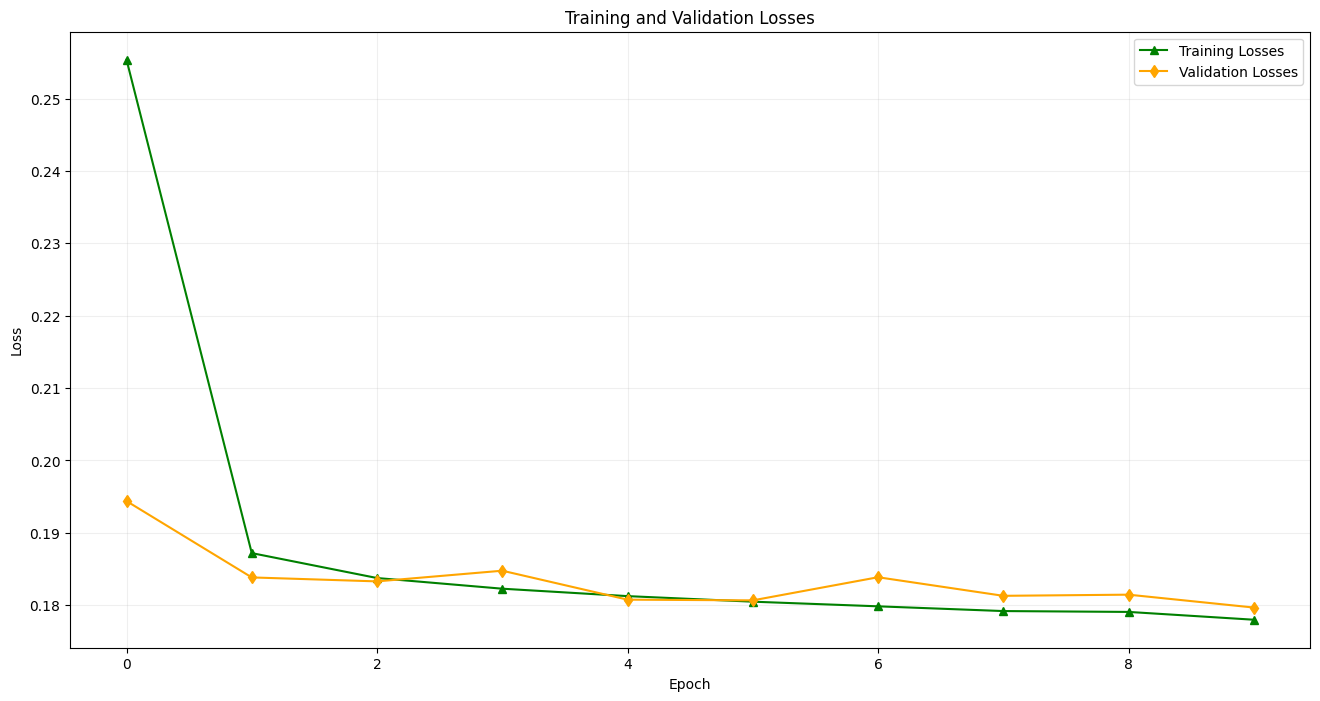

In [13]:
train_losses, val_losses = train_model(
        model=model,
        epochs=10,
        train_dataloader=std_train_dataloader,
        val_dataloader=std_val_dataloader,
        scheduler=scheduler,
        model_file="models/fire_predictor_lrg.pth"
    )

plot_losses(train_losses, val_losses, "images/fire_predictor_lrg.png")

In [14]:
def test_model_binary_classwise(model, test_dataloader):
    model.eval()
    
    safe_ious, risky_ious = [], []
    safe_dices, risky_dices = [], []
    
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for img_mask in tqdm(test_dataloader, position=0, leave=True, desc="Testing Model"):
            img = img_mask[0].float().to(device)
            mask = img_mask[1].float().unsqueeze(1).to(device) # Shape [N, 1, H, W]
            
            logits = model(img)
            probs = torch.sigmoid(logits)
            
            # Standard binary stats (Class 1 is positive class, Class 0 is negative class)
            tp, fp, fn, tn = smp.metrics.get_stats(
                probs, 
                mask.long(), 
                mode='binary', 
                threshold=0.5
            )
            
            # Epsilon prevents division by zero
            eps = 1e-7
            
            # 1. Compute Risky (Class 1) scores
            risky_iou = torch.mean(tp / (tp + fp + fn + eps))
            risky_dice = torch.mean((2 * tp) / (2 * tp + fp + fn + eps))
            
            # 2. Compute Safe (Class 0) scores (True Negatives become True Positives for Safe class)
            safe_iou = torch.mean(tn / (tn + fn + fp + eps))
            safe_dice = torch.mean((2 * tn) / (2 * tn + fn + fp + eps))
            
            safe_ious.append(safe_iou.item())
            risky_ious.append(risky_iou.item())
            safe_dices.append(safe_dice.item())
            risky_dices.append(risky_dice.item())
            
    print("-" * 40)
    print(f"Safe Class (0)  | Mean IoU: {np.mean(safe_ious):.4f} | Mean Dice: {np.mean(safe_dices):.4f}")
    print(f"Risky Class (1) | Mean IoU: {np.mean(risky_ious):.4f} | Mean Dice: {np.mean(risky_dices):.4f}")
    print("-" * 40)
    
    return np.mean(risky_ious), np.mean(risky_dices)


In [15]:
test_unet = UNet(in_channels=3, num_classes=1).to(device)
test_unet.load_state_dict(torch.load("models/fire_predictor_lrg.pth", weights_only=True))
test_iou, test_dice = test_model_binary_classwise(test_unet, std_test_dataloader)


Testing Model: 100%|██████████| 188/188 [01:12<00:00,  2.60it/s]

----------------------------------------
Safe Class (0)  | Mean IoU: 0.9422 | Mean Dice: 0.9698
Risky Class (1) | Mean IoU: 0.6205 | Mean Dice: 0.7564
----------------------------------------


## Visualize Results

In [16]:
def visualize_predictions(model, dataset, num_samples=3, device=None):
    if device is None:
        device = next(model.parameters()).device
        
    model.eval()
    
    # Binary color map: 0 -> Green (Safe), 1 -> Red (Risky)
    colors = ['#2e7d32', '#ff3d00']
    cmap = ListedColormap(colors)
    
    safe_patch = mpatches.Patch(color='#2e7d32', label='Safe (0)')
    risky_patch = mpatches.Patch(color='#ff3d00', label='Risky (1)')
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for i in range(num_samples):
        idx = random.randint(0, len(dataset) - 1)
        img_tensor, mask_tensor = dataset[idx]
        
        # Denormalize image
        img_display = img_tensor.permute(1, 2, 0).numpy()
        img_display = img_display * 0.5 + 0.5
        img_display = np.clip(img_display, 0, 1)
        
        # Ground truth mask
        mask_display = mask_tensor.numpy()
        
        # Binary prediction (Sigmoid + Threshold at 0.5)
        img_input = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(img_input)
            probs = torch.sigmoid(logits)
            pred = (probs.squeeze(0).squeeze(0) > 0.5).long().cpu().numpy()
            
        # Plot
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Input Image (Sample {idx})")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask_display, cmap=cmap, vmin=0, vmax=1)
        axes[i, 1].set_title("Ground Truth (Safe/Risky)")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred, cmap=cmap, vmin=0, vmax=1)
        axes[i, 2].set_title("Model Prediction")
        axes[i, 2].axis('off')
        
    fig.legend(handles=[safe_patch, risky_patch], 
               loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet(in_channels=3, num_classes=1).to(device)
model.load_state_dict(torch.load("models/fire_predictor_lrg.pth", weights_only=True))


<All keys matched successfully>

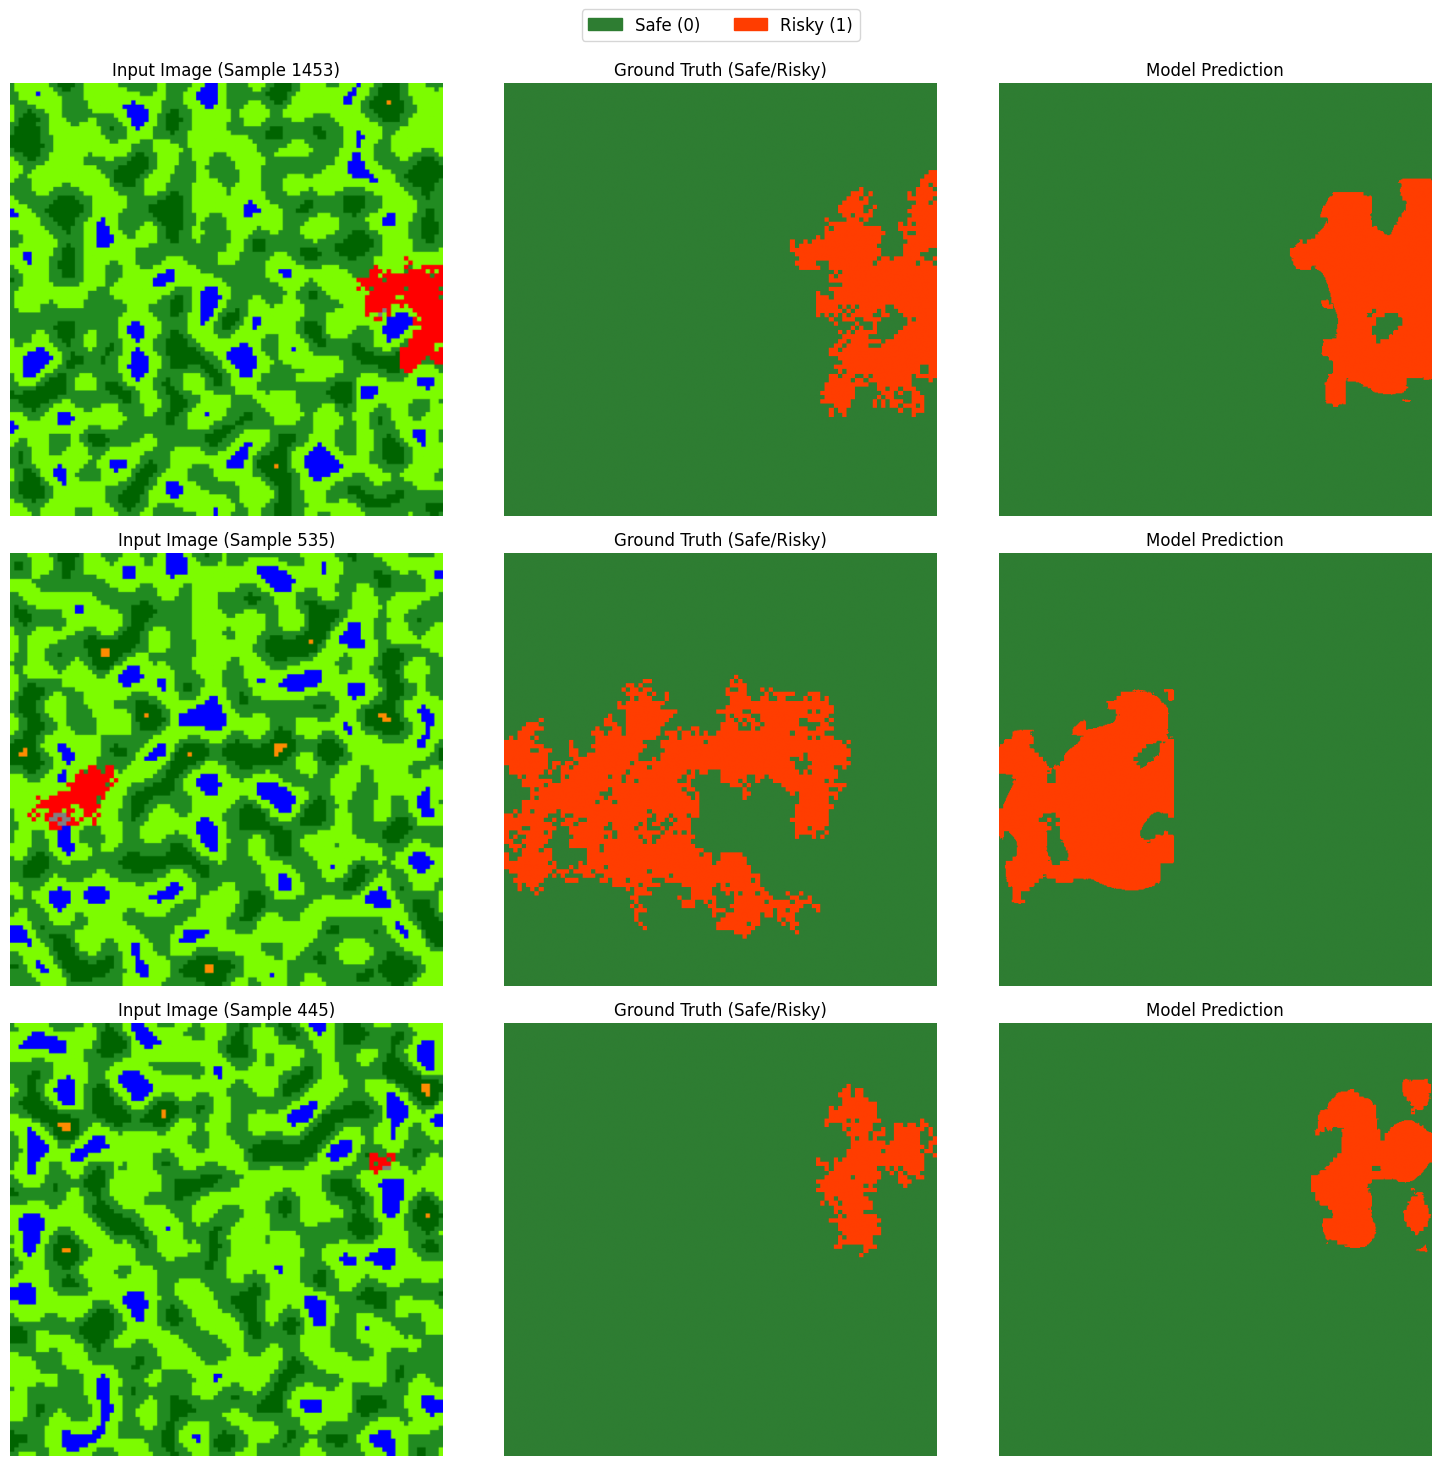

In [18]:
visualize_predictions(model, std_test_dataset, num_samples=3)